In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Please enable GPU from Runtime > Change runtime type > T4 GPU.")

Mounted at /content/drive
Device: cuda
GPU Name: Tesla T4


In [2]:
import os

BASE_DIR = "/content/drive/MyDrive/GM_Assignment3_Food101"
RESNET_DIR = os.path.join(BASE_DIR, "ResNet50")

folders = [
    BASE_DIR,
    RESNET_DIR,
    os.path.join(RESNET_DIR, "best_model"),
    os.path.join(RESNET_DIR, "checkpoints"),
    os.path.join(RESNET_DIR, "history"),
    os.path.join(RESNET_DIR, "plots"),
    os.path.join(RESNET_DIR, "results"),
    "/content/dataset"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")
print("Base directory:", BASE_DIR)
print("ResNet directory:", RESNET_DIR)

Project folders created successfully.
Base directory: /content/drive/MyDrive/GM_Assignment3_Food101
ResNet directory: /content/drive/MyDrive/GM_Assignment3_Food101/ResNet50


Kaggle API Key Upload + Dataset Download

In [4]:
from google.colab import files
import os, shutil

print("Please upload your kaggle.json file.")
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)

for filename in uploaded.keys():
    if filename == "kaggle.json":
        shutil.copy(filename, "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API key setup completed.")

!kaggle datasets download -d erika7/food-101-small-10-categories-trainvaltest-split -p /content/dataset --unzip

print("Dataset downloaded and unzipped.")

Please upload your kaggle.json file.


Saving kaggle.json to kaggle.json
Kaggle API key setup completed.
Dataset URL: https://www.kaggle.com/datasets/erika7/food-101-small-10-categories-trainvaltest-split
License(s): CC0-1.0
100% 147M/147M [00:01<00:00, 134MB/s]

Dataset downloaded and unzipped.


Check Dataset Folder Structure

In [5]:
import os

dataset_root = "/content/dataset"

print("Main dataset folders/files:")
print(os.listdir(dataset_root))

for root, dirs, files in os.walk(dataset_root):
    level = root.replace(dataset_root, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = "  " * (level + 1)
    for f in files[:5]:
        print(f"{sub_indent}{f}")

    if level >= 2:
        dirs[:] = []

Main dataset folders/files:
['test', 'train', 'validation']
dataset/
  test/
    pizza/
      1555015.jpg
      1916846.jpg
      375401.jpg
      2707814.jpg
      513754.jpg
    ramen/
      1732892.jpg
      1858257.jpg
      80967.jpg
      1959842.jpg
      906209.jpg
    sushi/
      1954998.jpg
      623621.jpg
      2385731.jpg
      2270794.jpg
      2961720.jpg
    hamburger/
      629010.jpg
      350854.jpg
      3030255.jpg
      992429.jpg
      3791190.jpg
    chocolate_cake/
      601217.jpg
      1057503.jpg
      1948508.jpg
      3058055.jpg
      3365013.jpg
    chicken_curry/
      737216.jpg
      3542597.jpg
      2591392.jpg
      137997.jpg
      170086.jpg
    tacos/
      2974711.jpg
      606860.jpg
      3275812.jpg
      955551.jpg
      1622614.jpg
    fish_and_chips/
      2402597.jpg
      990368.jpg
      3466493.jpg
      302932.jpg
      1128671.jpg
    pad_thai/
      1400112.jpg
      2075635.jpg
      200533.jpg
      393073.jpg
      1437282.jpg


Count Images and Classes

In [6]:
import os

train_dir = "/content/dataset/train"
val_dir = "/content/dataset/validation"
test_dir = "/content/dataset/test"

classes = sorted(os.listdir(train_dir))
num_classes = len(classes)

print("Classes:", classes)
print("Number of classes:", num_classes)

def count_images(folder):
    total = 0
    class_counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            count = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            class_counts[cls] = count
            total += count
    return total, class_counts

train_total, train_counts = count_images(train_dir)
val_total, val_counts = count_images(val_dir)
test_total, test_counts = count_images(test_dir)

print("\nTrain images:", train_total)
print("Validation images:", val_total)
print("Test images:", test_total)

print("\nTrain class counts:")
for cls, count in train_counts.items():
    print(cls, ":", count)

Classes: ['chicken_curry', 'chocolate_cake', 'fish_and_chips', 'hamburger', 'ice_cream', 'pad_thai', 'pizza', 'ramen', 'sushi', 'tacos']
Number of classes: 10

Train images: 2400
Validation images: 300
Test images: 300

Train class counts:
chicken_curry : 240
chocolate_cake : 240
fish_and_chips : 240
hamburger : 240
ice_cream : 240
pad_thai : 240
pizza : 240
ramen : 240
sushi : 240
tacos : 240


Data Transforms + DataLoaders

In [7]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes

print("Class names:", class_names)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

images, labels = next(iter(train_loader))
print("One batch image shape:", images.shape)
print("One batch label shape:", labels.shape)

Class names: ['chicken_curry', 'chocolate_cake', 'fish_and_chips', 'hamburger', 'ice_cream', 'pad_thai', 'pizza', 'ramen', 'sushi', 'tacos']
Train batches: 75
Validation batches: 10
Test batches: 10
One batch image shape: torch.Size([32, 3, 224, 224])
One batch label shape: torch.Size([32])


Load Pretrained ResNet50 + Replace Final Layer

In [8]:
import torch.nn as nn
from torchvision import models

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model: ResNet50")
print("Input classes:", num_classes)
print("Final layer input features:", in_features)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Model is on:", next(model.parameters()).device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 160MB/s]


Model: ResNet50
Input classes: 10
Final layer input features: 2048
Total parameters: 23528522
Trainable parameters: 23528522
Model is on: cuda:0


Loss Function, Optimizer, and Scheduler

In [9]:
import torch.optim as optim

EPOCHS = 10
LEARNING_RATE = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss function: CrossEntropyLoss")
print("Optimizer: AdamW")
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)
print("Scheduler: ReduceLROnPlateau")

Loss function: CrossEntropyLoss
Optimizer: AdamW
Learning rate: 0.0001
Epochs: 10
Scheduler: ReduceLROnPlateau


Training and Validation Functions

In [10]:
import time

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

print("Training and validation functions are ready.")

Training and validation functions are ready.


Train Model + Save Best Model

In [11]:
import json
import os
import time
import torch

best_val_acc = 0.0
best_model_path = os.path.join(RESNET_DIR, "best_model", "resnet50_best.pth")
history_path = os.path.join(RESNET_DIR, "history", "resnet50_history.json")

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time": []
}

total_start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    epoch_time = time.time() - epoch_start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["epoch_time"].append(epoch_time)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved at epoch {epoch+1}")

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} "
        f"Time: {epoch_time:.2f}s"
    )

total_training_time = time.time() - total_start_time

history["total_training_time"] = total_training_time
history["best_val_acc"] = best_val_acc

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("\nTraining completed.")
print("Best validation accuracy:", best_val_acc)
print("Total training time:", total_training_time, "seconds")
print("Best model path:", best_model_path)
print("History path:", history_path)

Best model saved at epoch 1
Epoch [1/10] Train Loss: 1.4256 | Train Acc: 0.6500 Val Loss: 0.5117 | Val Acc: 0.8467 Time: 27.68s
Best model saved at epoch 2
Epoch [2/10] Train Loss: 0.4134 | Train Acc: 0.8850 Val Loss: 0.3393 | Val Acc: 0.8967 Time: 26.56s
Best model saved at epoch 3
Epoch [3/10] Train Loss: 0.2226 | Train Acc: 0.9387 Val Loss: 0.2949 | Val Acc: 0.9033 Time: 27.60s
Epoch [4/10] Train Loss: 0.1249 | Train Acc: 0.9675 Val Loss: 0.3096 | Val Acc: 0.9033 Time: 29.46s
Epoch [5/10] Train Loss: 0.0805 | Train Acc: 0.9771 Val Loss: 0.3082 | Val Acc: 0.9033 Time: 29.18s
Best model saved at epoch 6
Epoch [6/10] Train Loss: 0.0511 | Train Acc: 0.9867 Val Loss: 0.3170 | Val Acc: 0.9133 Time: 28.47s
Best model saved at epoch 7
Epoch [7/10] Train Loss: 0.0421 | Train Acc: 0.9904 Val Loss: 0.3090 | Val Acc: 0.9167 Time: 29.16s
Epoch [8/10] Train Loss: 0.0304 | Train Acc: 0.9950 Val Loss: 0.3354 | Val Acc: 0.9133 Time: 29.31s
Epoch [9/10] Train Loss: 0.0268 | Train Acc: 0.9933 Val Loss

Plot Loss and Accuracy Curves

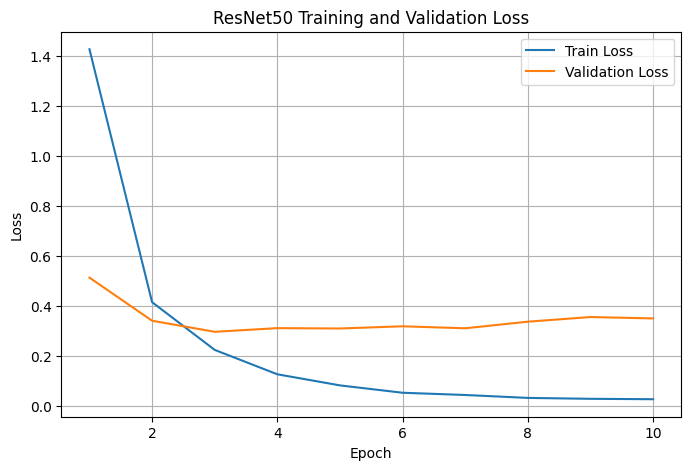

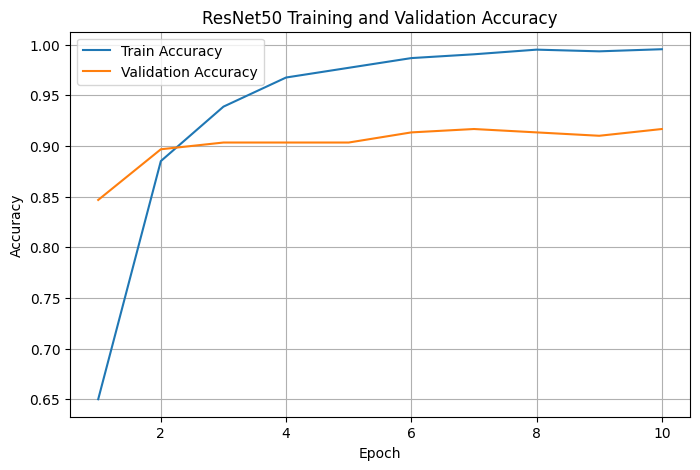

Loss curve saved at: /content/drive/MyDrive/GM_Assignment3_Food101/ResNet50/plots/resnet50_loss_curve.png
Accuracy curve saved at: /content/drive/MyDrive/GM_Assignment3_Food101/ResNet50/plots/resnet50_accuracy_curve.png


In [12]:
import matplotlib.pyplot as plt
import json
import os

history_path = os.path.join(RESNET_DIR, "history", "resnet50_history.json")

with open(history_path, "r") as f:
    history = json.load(f)

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training and Validation Loss")
plt.legend()
plt.grid(True)

loss_plot_path = os.path.join(RESNET_DIR, "plots", "resnet50_loss_curve.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training and Validation Accuracy")
plt.legend()
plt.grid(True)

acc_plot_path = os.path.join(RESNET_DIR, "plots", "resnet50_accuracy_curve.png")
plt.savefig(acc_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved at:", loss_plot_path)
print("Accuracy curve saved at:", acc_plot_path)

Test Evaluation + Metrics

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch

# Load best model
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Accuracy
test_acc = np.mean(np.array(all_preds) == np.array(all_labels))

print("Test Accuracy:", test_acc)

# Classification Report
report = classification_report(all_labels, all_preds, target_names=class_names)
print("\nClassification Report:\n")
print(report)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:\n", cm)

Test Accuracy: 0.93

Classification Report:

                precision    recall  f1-score   support

 chicken_curry       0.80      0.80      0.80        30
chocolate_cake       0.97      1.00      0.98        30
fish_and_chips       0.93      0.93      0.93        30
     hamburger       0.97      0.97      0.97        30
     ice_cream       0.97      1.00      0.98        30
      pad_thai       0.94      0.97      0.95        30
         pizza       0.97      0.93      0.95        30
         ramen       0.96      0.90      0.93        30
         sushi       0.90      0.90      0.90        30
         tacos       0.90      0.90      0.90        30

      accuracy                           0.93       300
     macro avg       0.93      0.93      0.93       300
  weighted avg       0.93      0.93      0.93       300


Confusion Matrix:
 [[24  1  1  0  0  0  0  1  1  2]
 [ 0 30  0  0  0  0  0  0  0  0]
 [ 1  0 28  0  0  0  0  0  1  0]
 [ 0  0  0 29  1  0  0  0  0  0]
 [ 0  0  0  0 30